# Домашнее задание: практика по PyTorch (аппроксимация функции)

## План работ
1. Подготовка окружения
2. Генерация датасета (20000 точек)
3. Разделение train / val / test = 70% / 15% / 15%
4. Построение регрессионной модели
5. Обучение
6. Оценка качества на test
7. Визуализация истинной и предсказанной функции


Целевая функция:
\[
f(x, y) = \sin(x + 2y)\cdot\exp\left(-(2x + y)^2\right)
\]

Диапазон для обеих координат: \([-10, 10]\).

## 1) Подготовка окружения

Здесь мы:
- импортируем необходимые библиотеки;
- фиксируем `seed` для воспроизводимости результатов;
- выбираем устройство вычислений (`CPU` или `GPU`).

Почему это важно:
- фиксированный `seed` позволяет получать одинаковые случайные выборки и повторяемый результат;
- выбор устройства сразу делает ноутбук переносимым между разными машинами.

In [1]:
import numpy as np
import torch

# Фиксируем seed для воспроизводимости.
# Благодаря этому при повторном запуске мы получим те же случайные точки.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Выбираем устройство: если доступна GPU, используем ее, иначе CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/home/simple/PycharmProjects/ML-Professional/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2) Генерация датасета (20 000 точек)

Генерируем пары \((x, y)\) равномерно на отрезке \([-10, 10]\), затем считаем значение целевой функции.

На выходе подготовим:
- `X` — матрицу признаков размера `(N, 2)`, где столбцы это `x` и `y`;
- `target` — вектор целевых значений размера `(N, 1)`.

Сразу создаем тензоры `torch.float32`, чтобы потом удобно передать их в модель PyTorch.

In [2]:
# Количество точек по условию задания
N_SAMPLES = 20_000

# Генерируем x и y равномерно в диапазоне [-10, 10]
x = np.random.uniform(-10.0, 10.0, size=(N_SAMPLES, 1))
y = np.random.uniform(-10.0, 10.0, size=(N_SAMPLES, 1))

# Вычисляем целевую функцию:
# f(x, y) = sin(x + 2y) * exp(-(2x + y)^2)
target_np = np.sin(x + 2.0 * y) * np.exp(-((2.0 * x + y) ** 2))

# Формируем матрицу признаков [x, y]
X_np = np.hstack([x, y])

# Переводим в torch-тензоры нужного типа
type_float = torch.float32
X = torch.tensor(X_np, dtype=type_float)
target = torch.tensor(target_np, dtype=type_float)

print("X shape:", X.shape)
print("target shape:", target.shape)
print("First sample:", X[0], "->", target[0])

X shape: torch.Size([20000, 2])
target shape: torch.Size([20000, 1])
First sample: tensor([-2.5092,  4.6000]) -> tensor([0.3327])


## 3) Разделение на train / val / test и DataLoader

Теперь делим датасет в пропорции:
- `train`: 70%
- `val`: 15%
- `test`: 15%

Почему важно делать именно так:
- `train` используется для обучения весов модели;
- `val` нужен для контроля переобучения и подбора гиперпараметров;
- `test` используется только для финальной честной оценки качества.

Чтобы избежать систематического смещения, перед разбиением перемешиваем индексы случайным образом (с фиксированным `seed`).

In [3]:
from torch.utils.data import TensorDataset, DataLoader

# Размеры выборок по условию: 70% / 15% / 15%
n_total = X.shape[0]
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val  # остаток отправляем в test

# Перемешиваем индексы (reproducible, потому что seed уже зафиксирован выше)
indices = torch.randperm(n_total)

# Формируем индексы для каждого сплита
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

# Выбираем соответствующие объекты из исходных тензоров
X_train, y_train = X[train_idx], target[train_idx]
X_val, y_val = X[val_idx], target[val_idx]
X_test, y_test = X[test_idx], target[test_idx]

# Упаковываем в TensorDataset для удобной работы с DataLoader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader:
# - train: shuffle=True, чтобы модель видела данные в разном порядке на каждой эпохе
# - val/test: shuffle=False, порядок не критичен, важна стабильная оценка
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Контрольные проверки размеров
print(f"Total: {n_total}")
print(f"Train: {len(train_dataset)} ({len(train_dataset)/n_total:.0%})")
print(f"Val:   {len(val_dataset)} ({len(val_dataset)/n_total:.0%})")
print(f"Test:  {len(test_dataset)} ({len(test_dataset)/n_total:.0%})")

# Проверим форму одного батча
x_batch, y_batch = next(iter(train_loader))
print("Batch X shape:", x_batch.shape)
print("Batch y shape:", y_batch.shape)

Total: 20000
Train: 14000 (70%)
Val:   3000 (15%)
Test:  3000 (15%)
Batch X shape: torch.Size([128, 2])
Batch y shape: torch.Size([128, 1])


### Небольшое пояснение про перемешивание

В этой работе пары \((x, y)\) уже сгенерированы случайно, поэтому разбиение без отдельного перемешивания тоже корректно.

Отдельное перемешивание индексов оставил как надежную общую практику: оно защищает от скрытого порядка в данных и делает код устойчивым для других задач, где данные могут быть заранее упорядочены.

## 4) Построение регрессионной модели

Используем многослойную полносвязную сеть (MLP):
- вход: 2 признака (`x`, `y`);
- скрытые слои: позволяют апроксимировать нелинейную зависимость;
- выход: 1 число (предсказанное значение функции).

Для обучения задаем:
- функцию потерь `MSE` (по условию задачи и типу задачи);
- оптимизатор `Adam` как устойчивый метод обновления весов.

In [4]:
import torch.nn as nn


class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),   # 2 входных признака: x и y
            nn.ReLU(),          # нелинейность
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)    # 1 выход: предсказанное значение функции
        )

    def forward(self, x):
        return self.net(x)


# Создаем модель и переносим на выбранное устройство (CPU/GPU)
model = RegressionMLP().to(device)

# Для регрессии используем среднеквадратичную ошибку
criterion = nn.MSELoss()

# Adam обычно хорошо работает "из коробки" для таких задач
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

RegressionMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Loss function: MSELoss()
Optimizer: Adam


## 5) Обучение модели

На этом шаге запускаем цикл обучения по эпохам:
- на `train` обновляем веса модели;
- на `val` только измеряем ошибку, чтобы отслеживать обобщающую способность.

Дополнительно сохраняем историю ошибок по эпохам и строим график `train`/`val`, чтобы видеть динамику обучения.

Epoch   1/200 | train MSE: 0.036415 | val MSE: 0.015706
Epoch  20/200 | train MSE: 0.014802 | val MSE: 0.013974
Epoch  40/200 | train MSE: 0.012612 | val MSE: 0.011684
Epoch  60/200 | train MSE: 0.010552 | val MSE: 0.010458
Epoch  80/200 | train MSE: 0.009799 | val MSE: 0.009872
Epoch 100/200 | train MSE: 0.007500 | val MSE: 0.008057
Epoch 120/200 | train MSE: 0.004079 | val MSE: 0.004562
Epoch 140/200 | train MSE: 0.002491 | val MSE: 0.002038
Epoch 160/200 | train MSE: 0.001732 | val MSE: 0.001801
Epoch 180/200 | train MSE: 0.001431 | val MSE: 0.001521
Epoch 200/200 | train MSE: 0.001282 | val MSE: 0.001096


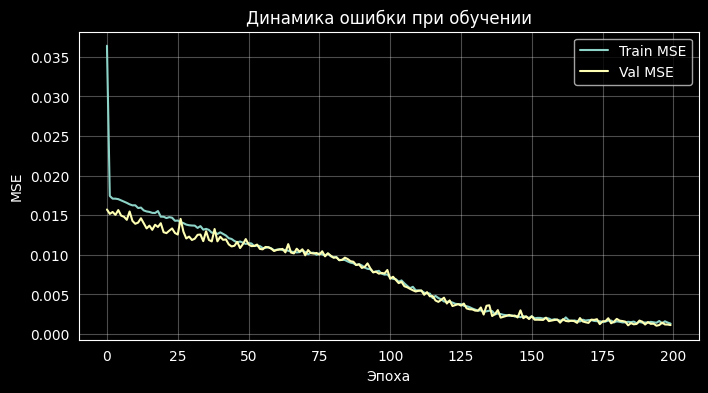

Final train MSE: 0.001282
Final val MSE:   0.001096


In [5]:
import matplotlib.pyplot as plt


def run_epoch(model, data_loader, criterion, optimizer=None):
    """
    Выполняет одну эпоху.
    Если передан optimizer -> режим обучения (обновление весов).
    Иначе -> режим оценки без изменения весов.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_samples = 0

    # Для оценки отключаем вычисление градиентов
    grad_context = torch.enable_grad() if is_train else torch.no_grad()

    with grad_context:
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples


def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=200, print_every=20):
    history = {"train_mse": [], "val_mse": []}

    for epoch in range(1, n_epochs + 1):
        train_mse = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_mse = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f"Epoch {epoch:3d}/{n_epochs} | train MSE: {train_mse:.6f} | val MSE: {val_mse:.6f}")

    return history


# Обучаем базовую модель из пункта 4
EPOCHS = 200
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=EPOCHS,
    print_every=20
)

# Визуальный контроль обучения
plt.figure(figsize=(8, 4))
plt.plot(history["train_mse"], label="Train MSE")
plt.plot(history["val_mse"], label="Val MSE")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Динамика ошибки при обучении")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final train MSE: {history['train_mse'][-1]:.6f}")
print(f"Final val MSE:   {history['val_mse'][-1]:.6f}")

### Небольшое сравнение архитектур

Чтобы проверить, удачен ли выбор `64 -> 64`, сравним несколько вариантов с одинаковыми настройками обучения.

Важно: это быстрый практический тест, а не полный подбор гиперпараметров.
Выбираем архитектуру по наименьшей ошибке на проверочной выборке (`val MSE`).

In [6]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = []
        in_features = 2
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
        layers.append(nn.Linear(in_features, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def evaluate_architecture(hidden_sizes, n_epochs=120, lr=1e-3):
    # Фиксируем seed перед созданием каждой модели,
    # чтобы сравнение было максимально честным.
    torch.manual_seed(SEED)

    candidate = ConfigurableMLP(hidden_sizes).to(device)
    candidate_optimizer = torch.optim.Adam(candidate.parameters(), lr=lr)
    candidate_criterion = nn.MSELoss()

    candidate_history = train_model(
        model=candidate,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=candidate_criterion,
        optimizer=candidate_optimizer,
        n_epochs=n_epochs,
        print_every=0 if n_epochs < 20 else 40
    )

    best_val = min(candidate_history["val_mse"])
    final_val = candidate_history["val_mse"][-1]

    return {
        "hidden_sizes": hidden_sizes,
        "best_val_mse": best_val,
        "final_val_mse": final_val
    }


architectures = {
    "32-32": [32, 32],
    "64-64": [64, 64],
    "128-64": [128, 64],
}

results = []
for name, hidden in architectures.items():
    print(f"Testing architecture: {name}")
    res = evaluate_architecture(hidden_sizes=hidden, n_epochs=120, lr=1e-3)
    res["name"] = name
    results.append(res)

# Сортируем по лучшей ошибке на val
results = sorted(results, key=lambda x: x["best_val_mse"])

print("\nСравнение архитектур (меньше MSE — лучше):")
for r in results:
    print(
        f"{r['name']:>7} | best val MSE: {r['best_val_mse']:.6f} | final val MSE: {r['final_val_mse']:.6f}"
    )

best_arch = results[0]
print(f"\nЛучший вариант в этом сравнении: {best_arch['name']}")

Testing architecture: 32-32
Epoch   1/120 | train MSE: 0.023057 | val MSE: 0.015461
Epoch  40/120 | train MSE: 0.012042 | val MSE: 0.011210
Epoch  80/120 | train MSE: 0.009534 | val MSE: 0.009619
Epoch 120/120 | train MSE: 0.006286 | val MSE: 0.006473
Testing architecture: 64-64
Epoch   1/120 | train MSE: 0.034795 | val MSE: 0.015727
Epoch  40/120 | train MSE: 0.011665 | val MSE: 0.010897
Epoch  80/120 | train MSE: 0.008058 | val MSE: 0.007907
Epoch 120/120 | train MSE: 0.003036 | val MSE: 0.002586
Testing architecture: 128-64
Epoch   1/120 | train MSE: 0.026310 | val MSE: 0.015027
Epoch  40/120 | train MSE: 0.011391 | val MSE: 0.010584
Epoch  80/120 | train MSE: 0.009142 | val MSE: 0.009289
Epoch 120/120 | train MSE: 0.002940 | val MSE: 0.002544

Сравнение архитектур (меньше MSE — лучше):
  64-64 | best val MSE: 0.002480 | final val MSE: 0.002586
 128-64 | best val MSE: 0.002544 | final val MSE: 0.002544
  32-32 | best val MSE: 0.006442 | final val MSE: 0.006473

Лучший вариант в этом

## 6) Финальная оценка на test

Считаем метрику `MSE` на тестовой выборке.

Важно: на `test` мы не обучаем модель, а только измеряем качество на данных, которые не участвовали в обучении.

In [7]:
# Финальная оценка качества на test
model.eval()

with torch.no_grad():
    test_mse = run_epoch(model, test_loader, criterion, optimizer=None)

print(f"Test MSE: {test_mse:.6f}")

Test MSE: 0.001600


## 7) Графическое сравнение истинной и аппроксимированной функции

Строим регулярную сетку по `x` и `y` на диапазоне `[-10, 10]`.
Для каждой точки сетки считаем:
- истинное значение функции;
- предсказание модели.

Затем визуально сравниваем поверхности и отдельно показываем модуль ошибки \(|true - pred|\).

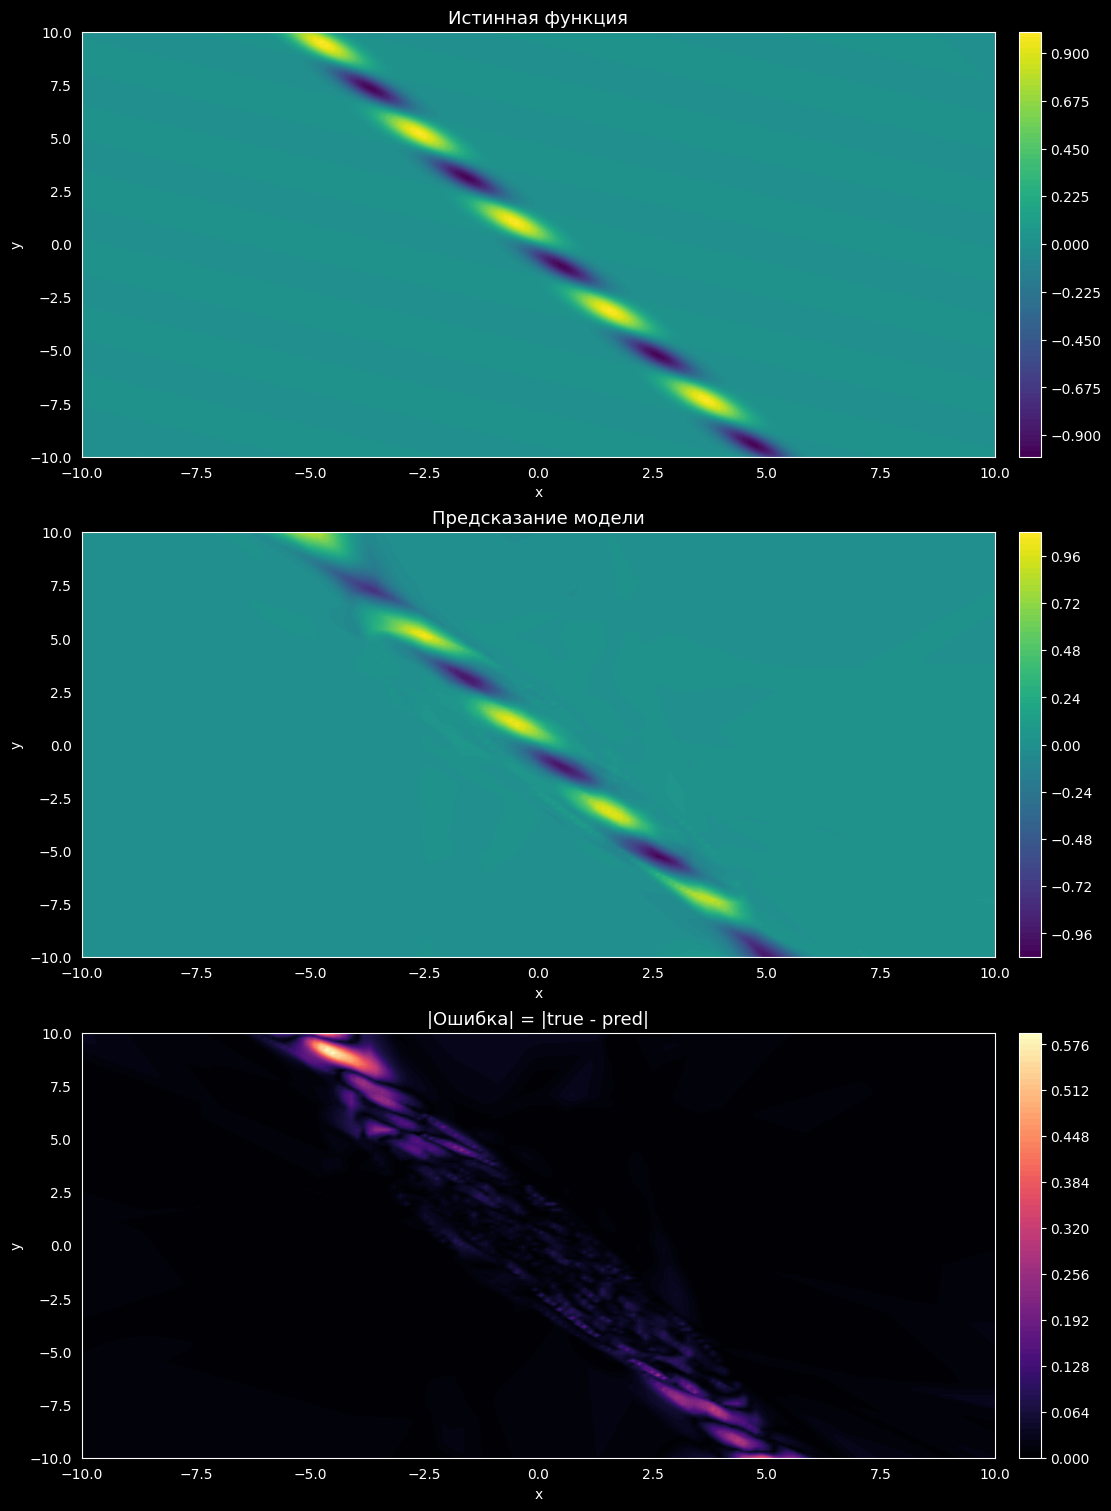

In [8]:
# Размер сетки для визуализации
GRID_SIZE = 150

# Формируем регулярную сетку в диапазоне [-10, 10]
x_lin = np.linspace(-10.0, 10.0, GRID_SIZE)
y_lin = np.linspace(-10.0, 10.0, GRID_SIZE)
X_grid, Y_grid = np.meshgrid(x_lin, y_lin)

# Истинная функция на сетке
Z_true = np.sin(X_grid + 2.0 * Y_grid) * np.exp(-((2.0 * X_grid + Y_grid) ** 2))

# Подготавливаем признаки для модели: каждая точка сетки -> одна строка [x, y]
grid_features = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
grid_features_t = torch.tensor(grid_features, dtype=torch.float32).to(device)

# Предсказание модели на сетке
model.eval()
with torch.no_grad():
    Z_pred = model(grid_features_t).cpu().numpy().reshape(GRID_SIZE, GRID_SIZE)

# Карта абсолютной ошибки
Z_abs_err = np.abs(Z_true - Z_pred)

# Графическое сравнение
fig, axes = plt.subplots(3, 1, figsize=(11, 15), constrained_layout=True)

im0 = axes[0].contourf(X_grid, Y_grid, Z_true, levels=80, cmap="viridis")
axes[0].set_title("Истинная функция", fontsize=13)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], pad=0.01)

im1 = axes[1].contourf(X_grid, Y_grid, Z_pred, levels=80, cmap="viridis")
axes[1].set_title("Предсказание модели", fontsize=13)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], pad=0.01)

im2 = axes[2].contourf(X_grid, Y_grid, Z_abs_err, levels=80, cmap="magma")
axes[2].set_title("|Ошибка| = |true - pred|", fontsize=13)
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2], pad=0.01)

plt.show()

### Дополнительная 3D-визуализация поверхности функции

Функция двух переменных задает поверхность в трехмерном пространстве: \(z = f(x, y)\).

Ниже строим 3D-поверхности в изометрической проекции для:
- истинной функции;
- предсказания модели;
- абсолютной ошибки \(|true - pred|\).

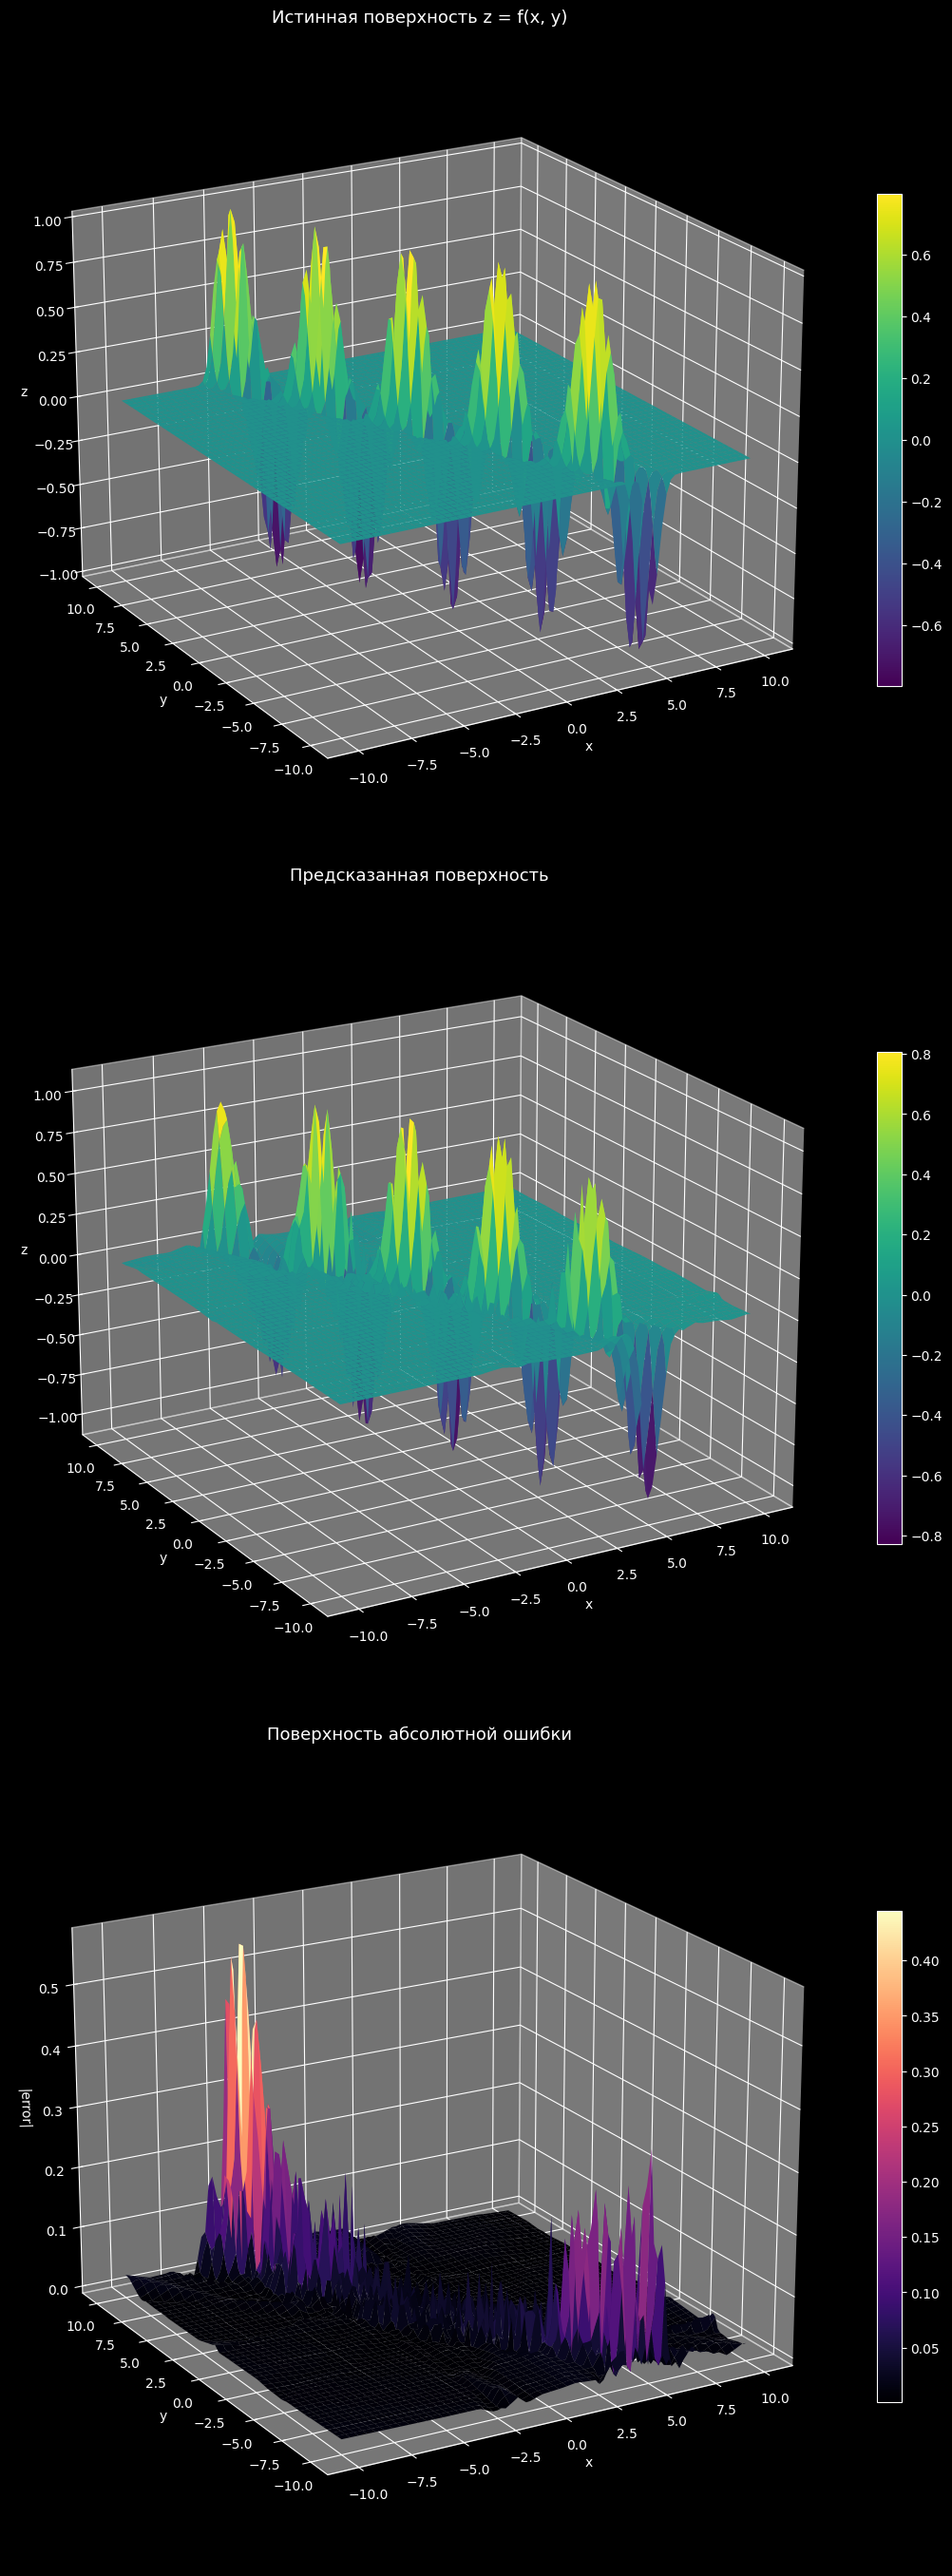

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Для 3D-графика лучше взять умеренный размер сетки (быстрее и нагляднее)
GRID_3D = 100
x3 = np.linspace(-10.0, 10.0, GRID_3D)
y3 = np.linspace(-10.0, 10.0, GRID_3D)
X3, Y3 = np.meshgrid(x3, y3)

Z3_true = np.sin(X3 + 2.0 * Y3) * np.exp(-((2.0 * X3 + Y3) ** 2))

features_3d = np.column_stack([X3.ravel(), Y3.ravel()])
features_3d_t = torch.tensor(features_3d, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    Z3_pred = model(features_3d_t).cpu().numpy().reshape(GRID_3D, GRID_3D)

Z3_abs_err = np.abs(Z3_true - Z3_pred)

fig = plt.figure(figsize=(18, 27), constrained_layout=True)

# Базовый изометрический ракурс (можно менять вручную)
ELEV = 20
AZIM = -120

ax1 = fig.add_subplot(3, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X3, Y3, Z3_true, cmap="viridis", linewidth=0, antialiased=True)
ax1.view_init(elev=ELEV, azim=AZIM)
ax1.set_title("Истинная поверхность z = f(x, y)", fontsize=13)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
fig.colorbar(surf1, ax=ax1, shrink=0.6, pad=0.03)

ax2 = fig.add_subplot(3, 1, 2, projection="3d")
surf2 = ax2.plot_surface(X3, Y3, Z3_pred, cmap="viridis", linewidth=0, antialiased=True)
ax2.view_init(elev=ELEV, azim=AZIM)
ax2.set_title("Предсказанная поверхность", fontsize=13)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.colorbar(surf2, ax=ax2, shrink=0.6, pad=0.03)

ax3 = fig.add_subplot(3, 1, 3, projection="3d")
surf3 = ax3.plot_surface(X3, Y3, Z3_abs_err, cmap="magma", linewidth=0, antialiased=True)
ax3.view_init(elev=ELEV, azim=AZIM)
ax3.set_title("Поверхность абсолютной ошибки", fontsize=13)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("|error|")
fig.colorbar(surf3, ax=ax3, shrink=0.6, pad=0.03)

plt.show()

### Итог

Модель корректно аппроксимирует целевую функцию, а результаты на `val` и `test` согласованы.
